# EDA 1 — cada dataset

Visão geral e padrões de cada base, uma de cada vez. A análise das bases juntas, com o equilíbrio do treino, da validação e do teste, está em `eda_2_conjunto.ipynb`.

| Dataset | Linhas | Verdadeiras | Enganosas (meio) | Falsas | Período | O que é |
|---|---:|---:|---:|---:|---|---|
| Fake.br | 7.185 | 3.585 | 0 | 3.600 | 2016–2018 | pares falsa × verdadeira do mesmo assunto (NILC/USP); só texto longo |
| FakeRecogna | 4.382 | 1.917 | 0 | 2.465 | 2019–2021 | boatos do Boatos.org × matérias do G1, UOL e Extra (UNESP), texto recoletado |
| FakeTrue.Br | 2.142 | 1.330 | 0 | 812 | 2018–2022 (maioria) | pares Boatos.org × G1/Folha/UOL do mesmo assunto; texto em minúsculas |
| Fact Check API | 10.341 | 94 | 3.122 | 7.125 | 2018–2026 | alegações com veredito de 10 agências brasileiras (Google Fact Check Tools) |
| FakenewsBR (agências) | 16.729 | 603 | 555 | 15.571 | 2016–2026 | alegações checadas por agências (e-farsas, G1 Fato ou Fake, Lupa...); falsos amostrados |
| FakenewsBR (mensagens) | 7.082 | 3.928 | 3 | 3.151 | 2018 e 2020 | mensagens de WhatsApp (eleição 2018) e de COVID anotadas; sem veredito |
| Portais | 21.222 | 21.222 | 0 | 0 | 2018–2026 | matérias de 9 portais de linhas editoriais variadas; verdadeiras por suposição |
| **Total** | **69.083** | **32.679** | **3.680** | **32.724** | | |

Linhas = registros no `dataset.jsonl`, depois de tirar duplicatas. Uso no modelo do jogo
(protocolo B, `split_produto`), depois do equilíbrio:

| Split | Verdadeiras | Enganosas | Falsas | Regra |
|---|---:|---:|---:|---|
| `treino` | 12.512 | 1.541 | 12.512 | pareadas 80%; checagens e portais até 2023; mensagens |
| `validacao` | 1.446 | 964 | 1.446 | pareadas 10%; checagens e portais de 2024 |
| `teste` | 1.638 | 1.092 | 1.638 | pareadas 10%; checagens e portais de 2025 em diante |

O que sobra no equilíbrio vira `reserva` (32.164 registros, quase todos portais e falsos da
FakenewsBR); sem data, anteriores a 2016 ou quase-duplicatas viram `fora` (2.130).
Contagem de 05/10/2026, gerada por `pesquisa/dados/preparar_dados.py`.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLASSES = ["verdadeiro", "enganoso", "falso"]
CORES = {"verdadeiro": "#2a78d6", "enganoso": "#e0a030", "falso": "#eb6834"}
TINTA_2 = "#52514e"
SPLITS = ["treino", "validacao", "teste"]
DATASETS = ["Fake.br", "FakeRecogna", "FakeTrue.Br", "Fact Check API",
            "FakenewsBR (agências)", "FakenewsBR (mensagens)", "Portais"]
MENSAGENS = {"FakeWhatsApp.BR_2018", "COVID19.BR"}
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 3.6), "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8, "axes.axisbelow": True, "axes.edgecolor": "#b8b7b0",
    "axes.labelcolor": TINTA_2, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "legend.frameon": False,
})
pd.set_option("display.max_colwidth", 120)

df = pd.read_json(RAIZ / "data" / "processed" / "dataset.jsonl", lines=True, dtype={"par_id": "Int64"})
NOMES = {"fakebr": "Fake.br", "fakerecogna": "FakeRecogna", "faketrue": "FakeTrue.Br",
         "factcheck": "Fact Check API", "verdadeiras": "Portais"}
df["dataset"] = df.base.map(NOMES)
fnb = df.base.eq("fakenewsbr")
df.loc[fnb & df.fonte.isin(MENSAGENS), "dataset"] = "FakenewsBR (mensagens)"
df.loc[fnb & ~df.fonte.isin(MENSAGENS), "dataset"] = "FakenewsBR (agências)"
df["data"] = pd.to_datetime(df["data"], errors="coerce")
df["ano"] = df.data.dt.year.astype("Int64")
df["tem_curto"] = df.texto_curto.notna()
curto = df.texto_curto.fillna("")
palavras = df.texto.str.findall(r"\w+")
df["palavras"] = palavras.str.len()
df["palavras_curto"] = curto.str.split().str.len()
df["% caixa alta"] = palavras.apply(lambda p: 100 * sum(w.isupper() and len(w) > 1 for w in p) / max(len(p), 1))
df["tem !"] = df.texto.str.contains("!", regex=False)
df["curto termina com ponto"] = curto.str.rstrip().str.endswith(".")
df["curto começa com vídeo/foto"] = curto.str.match(r"\W*(v[íi]deo|foto)", case=False)
df["curto em minúsculas"] = curto.ne("") & curto.eq(curto.str.lower())
print(f"{len(df):,} registros".replace(",", "."))

69.083 registros


In [2]:
def perfil(nome):
    d = df[df.dataset == nome]
    classes = [c for c in CLASSES if (d.veracidade == c).any()]
    visao = pd.DataFrame({
        "linhas": d.veracidade.value_counts().reindex(classes),
        "período": d.groupby("veracidade").ano.agg(lambda s: f"{s.min()}–{s.max()}" if s.notna().any() else "—"),
        "sem data": d.groupby("veracidade").ano.agg(lambda s: int(s.isna().sum())),
        "com texto curto (%)": d.groupby("veracidade").tem_curto.mean().mul(100).round(0),
        "palavras do texto (mediana)": d.groupby("veracidade").palavras.median(),
        "palavras do texto curto (mediana)": d[d.tem_curto].groupby("veracidade").palavras_curto.median(),
    }).reindex(classes)
    visao.loc["total"] = [len(d), f"{d.ano.min()}–{d.ano.max()}", int(d.ano.isna().sum()),
                          round(100 * d.tem_curto.mean()), d.palavras.median(), d[d.tem_curto].palavras_curto.median()]
    display(visao)

    fig, ax = plt.subplots(figsize=(9, 2.8))
    por_ano = d.groupby(["ano", "veracidade"]).size().unstack(fill_value=0).reindex(columns=classes, fill_value=0)
    base = np.zeros(len(por_ano))
    for c in classes:
        ax.bar(por_ano.index.astype(int), por_ano[c], bottom=base, color=CORES[c], label=c, width=0.7)
        base += por_ano[c].values
    ax.set_title(f"{nome}: registros por ano")
    ax.legend(loc="upper left")
    ax.grid(axis="x", visible=False)
    plt.show()

    formato = d.groupby("veracidade")[["% caixa alta", "tem !", "curto termina com ponto",
                                        "curto começa com vídeo/foto", "curto em minúsculas"]].mean()
    formato.iloc[:, 1:] *= 100
    print("Formato (% dos registros, exceto a 1ª coluna, que é a média de % de palavras em CAIXA ALTA):")
    display(formato.reindex(classes).round(1))

    print("Fontes mais frequentes por classe:")
    display(pd.concat({c: d[d.veracidade == c].fonte.value_counts().head(4) for c in classes})
            .rename("registros").to_frame())

    print("Uso no modelo do jogo (split_produto):")
    display(d.pivot_table(index="veracidade", columns="split_produto", values="id", aggfunc="size", fill_value=0)
            .reindex(index=classes, columns=[c for c in SPLITS + ["reserva", "fora"] if c in set(d.split_produto)]))

    print("Exemplos (texto curto, ou o início do texto):")
    for c in classes:
        for _, r in d[d.veracidade == c].sample(min(2, (d.veracidade == c).sum()), random_state=1).iterrows():
            t = r.texto_curto if r.tem_curto else r.texto[:160] + "…"
            print(f"  [{c}] {t}")

## 1. Fake.br

**O que é.** Corpus do NILC/USP com 3.600 pares de notícias falsas e verdadeiras sobre o
mesmo assunto, coletadas em 2016–2018. Lido do repositório original (commit `780f551`).

**Padrões.**
- **Só texto longo**: nenhum registro tem texto curto. Para o modelo de frases curtas, o
  Fake.br só conta se uma afirmação for extraída de cada matéria (LLM).
- **Tamanho entrega a classe**: as verdadeiras têm mediana de ~920 palavras, as falsas
  ~160. O corpus tem uma versão com os pares cortados no mesmo tamanho
  (`size_normalized_texts`), que vale usar.
- **Fonte**: 93% das falsas vêm de um único site (`diariodobrasil.org`); as verdadeiras, de
  G1 e Estadão.
- **Pares**: o sorteio 80/10/10 é por par, então as duas notícias do mesmo assunto ficam
  sempre do mesmo lado.

,linhas,período,sem data,com texto curto (%),palavras do texto (mediana),palavras do texto curto (mediana)
veracidade,,,,,,
verdadeiro,3585,2009–2018,2,0.0,923.0,NaN
falso,3600,2012–2018,1,0.0,157.0,NaN
total,7185,2009–2018,3,0.0,361.0,NaN


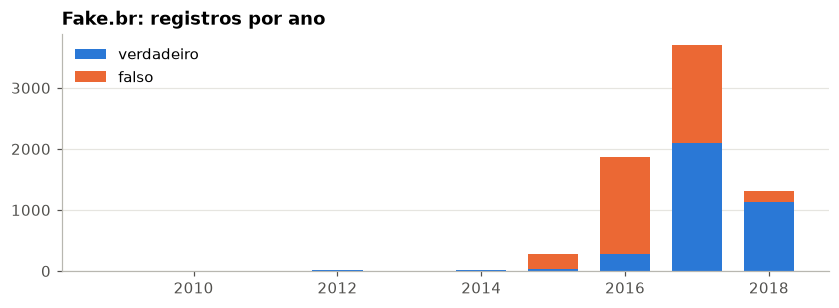

Formato (% dos registros, exceto a 1ª coluna, que é a média de % de palavras em CAIXA ALTA):


,% caixa alta,tem !,curto termina com ponto,curto começa com vídeo/foto,curto em minúsculas
veracidade,,,,,
verdadeiro,1.4,16.5,0.0,0.0,0.0
falso,1.8,33.5,0.0,0.0,0.0


Fontes mais frequentes por classe:


registros
           fonte                                  
verdadeiro g1.globo.com                       2289
           politica.estadao.com.br             749
           internacional.estadao.com.br        114
           cultura.estadao.com.br               95
falso      diariodobrasil.org                 3337
           afolhabrasil.com.br                 174
           thejornalbrasil.com.br               66
           ceticismopolitico.com                16

Uso no modelo do jogo (split_produto):


split_produto,treino,validacao,teste,reserva,fora
veracidade,,,,,
verdadeiro,2864,375,345,0,1
falso,2877,259,163,299,2


Exemplos (texto curto, ou o início do texto):
  [verdadeiro] Casa do Estudante em Fortaleza abriga jovens que apostaram na educação para superar dificuldades . O lugar resiste há 83 anos na capital, e recebe jovens que nã…
  [verdadeiro] O que esperar do novo mandato de Putin na Rússia?. Atual presidente do país deverá manter suas políticas, mas vai precisar conquistar o público jovem que não vi…
  [falso] "Laudo médico com diagnóstico de depressão e greve de fome" para escapar da cadeia.  Lula quer usar novamente o "coitadismo" para fugir das "grades".  O petista…
  [falso] Coreia faz desfile com homens-bomba: "Vamos espancar o louco do Trump com punhos nucleares".  O partido comunista de Kim Jong-un informou que está se preparando…


In [3]:
perfil("Fake.br")

## 2. FakeRecogna

**O que é.** Corpus da UNESP (2019–2021). Usamos só a URL e o rótulo do CSV e recoletamos o
texto: as falsas são o boato como circulou (Boatos.org), as verdadeiras são matérias do G1,
UOL e Extra. O sufixo `| G1` dos títulos é tirado no preparo.

**Padrões.**
- **Atalho de pontuação**: quase todas as falsas (98%) têm texto curto terminando com ponto
  final; nenhuma verdadeira termina assim (manchete não leva ponto). As falsas também têm
  muito mais `!` (55% × 5%) e CAIXA ALTA.
- **Tamanho**: falsas ~100 palavras, verdadeiras ~410.
- **Gêneros diferentes**: falsa = mensagem de rede social; verdadeira = matéria. O modelo
  pode separar pelo gênero, e não pela veracidade.

,linhas,período,sem data,com texto curto (%),palavras do texto (mediana),palavras do texto curto (mediana)
veracidade,,,,,,
verdadeiro,1917,2019–2021,0,100.0,412.0,13.0
falso,2465,2016–2021,0,100.0,100.0,25.0
total,4382,2016–2021,0,100.0,195.5,19.0


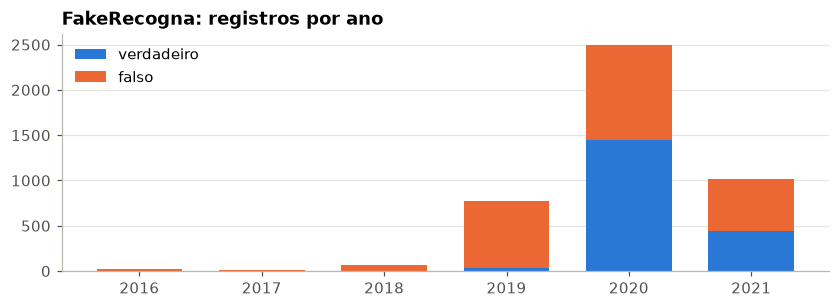

Formato (% dos registros, exceto a 1ª coluna, que é a média de % de palavras em CAIXA ALTA):


,% caixa alta,tem !,curto termina com ponto,curto começa com vídeo/foto,curto em minúsculas
veracidade,,,,,
verdadeiro,1.1,5.2,0.0,0.2,0.4
falso,9.7,54.6,97.7,9.8,0.0


Fontes mais frequentes por classe:


registros
           fonte                               
verdadeiro g1.globo.com                    1055
           uol.com.br                       473
           extra.globo.com                  220
           entretenimento.uol.com.br         63
falso      boatos.org                      2465

Uso no modelo do jogo (split_produto):


split_produto,treino,validacao,teste,reserva,fora
veracidade,,,,,
verdadeiro,1536,187,192,0,2
falso,1960,164,138,202,1


Exemplos (texto curto, ou o início do texto):
  [verdadeiro] Coronavírus: Ariana Grande doa dinheiro para fãs desempregados na pandemia
  [verdadeiro] Reforma tributária deve ser aprovada na Câmara até abril, diz Maia
  [falso] O apresentador Luciano Huck emprestou o seu avião, um jatinho com prefixo PP-HUC, para o ex-presidente Lula viajar de Curitiba para São Paulo.
  [falso] Cinco idosos morreram na cidade de Canela (RS) porque tomaram a vacina Coronavac (chinesa) contra a Covid-19. A mídia ficou caladinha.


In [4]:
perfil("FakeRecogna")

## 3. FakeTrue.Br

**O que é.** Corpus do FakeTrueBr (XVIII ERBD, 2023): 1.791 pares de falsa (Boatos.org) e
verdadeira (G1, Folha, UOL) do mesmo assunto. Depois das duplicatas, ficam 812 falsas (979
repetiam o FakeRecogna ou o próprio corpus) e 1.330 verdadeiras (a mesma matéria aparecia em
mais de um par).

**Padrões.**
- **Texto pré-processado na origem**: tudo em minúsculas, sem hífens e com números
  corrompidos ("carnaval de 223"). Isso é uma pista: nenhuma outra base vem em minúsculas.
- **Só as falsas têm texto curto** (o título do boato); as verdadeiras são só o corpo da
  matéria (~370 palavras × ~110 das falsas).
- **Data** sai da URL da verdadeira e vale para o par; 247 registros ficam sem data, mas o
  sorteio por par não depende dela.

,linhas,período,sem data,com texto curto (%),palavras do texto (mediana),palavras do texto curto (mediana)
veracidade,,,,,,
verdadeiro,1330,2007–2023,146,0.0,367.0,NaN
falso,812,2013–2023,101,100.0,108.0,12.0
total,2142,2007–2023,247,38.0,257.0,12.0


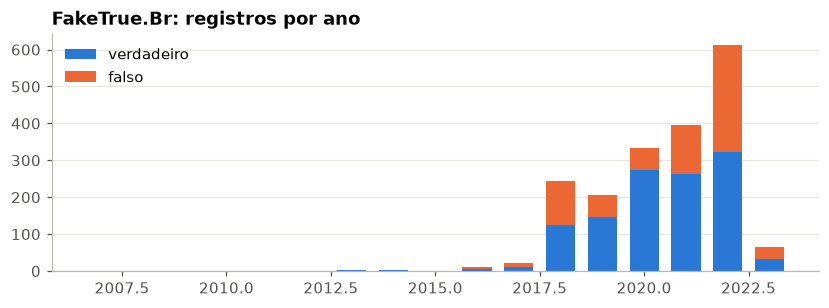

Formato (% dos registros, exceto a 1ª coluna, que é a média de % de palavras em CAIXA ALTA):


,% caixa alta,tem !,curto termina com ponto,curto começa com vídeo/foto,curto em minúsculas
veracidade,,,,,
verdadeiro,0.4,13.5,0.0,0.0,0.0
falso,0.0,47.5,0.0,3.7,100.0


Fontes mais frequentes por classe:


registros
           fonte                            
verdadeiro g1.globo.com                 1085
           noticias.uol.com.br            73
           piaui.folha.uol.com.br         58
           folha.uol.com.br               35
falso      boatos.org                    812

Uso no modelo do jogo (split_produto):


split_produto,treino,validacao,teste,reserva,fora
veracidade,,,,,
verdadeiro,1057,138,133,0,2
falso,645,59,42,64,2


Exemplos (texto curto, ou o início do texto):
  [verdadeiro] Lupa​: “Os números de óbitos anunciados pelas Secretarias de Saúde de Estados com maior índice de mortes por Covid-19 não batem com os registros de óbitos nos c…
  [verdadeiro] motoristas da alemanha fizeram uma paralisação com um milhão de carros abandonados para forçar o governo a recuar do aumento do preço do combustível? um post qu…
  [falso] lula acaba de declarar que vai fechar igrejas em 223
  [falso] jair bolsonaro propõe demissão em massa de professores do brasil


In [5]:
perfil("FakeTrue.Br")

## 4. Fact Check API

**O que é.** Alegações checadas por 10 agências brasileiras, coletadas pela Google Fact Check
Tools API. É a principal fonte de **enganosos** (o meio da escala) e de checagens recentes.

**Padrões.**
- **Quase não tem verdadeiros** (94): as agências checam o que é suspeito.
- **Formato homogêneo**: as três classes são alegações curtas (~12 palavras), no mesmo
  estilo, então aqui o formato não entrega a classe.
- **Uso por data**: até 2023 ensina o enganoso no treino; 2024 é a validação; 2025 em diante,
  o teste. A maior parte das checagens recentes fica na validação e no teste.

,linhas,período,sem data,com texto curto (%),palavras do texto (mediana),palavras do texto curto (mediana)
veracidade,,,,,,
verdadeiro,94,2016–2026,0,100.0,15.0,15.0
enganoso,3122,2015–2026,0,100.0,12.0,12.0
falso,7125,2016–2026,0,100.0,12.0,12.0
total,10341,2015–2026,0,100.0,12.0,12.0


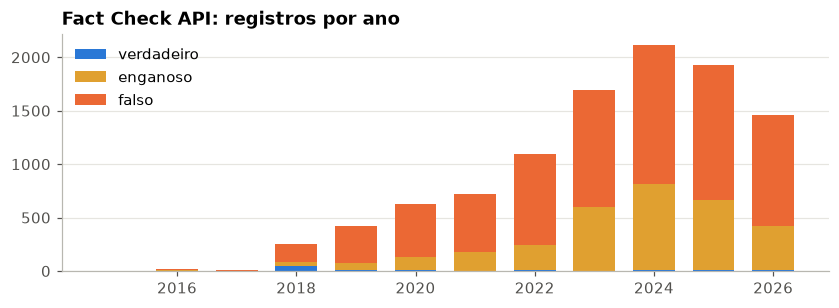

Formato (% dos registros, exceto a 1ª coluna, que é a média de % de palavras em CAIXA ALTA):


,% caixa alta,tem !,curto termina com ponto,curto começa com vídeo/foto,curto em minúsculas
veracidade,,,,,
verdadeiro,1.3,1.1,19.1,2.1,0.0
enganoso,2.2,1.8,12.9,8.8,0.2
falso,2.7,2.1,10.4,12.0,0.2


Fontes mais frequentes por classe:


registros
           fonte                            
verdadeiro eleicoes.apublica.org          39
           checamos.afp.com               16
           noticias.uol.com.br            14
           aosfatos.org                   12
enganoso   estadao.com.br               1403
           checamos.afp.com             1056
           noticias.uol.com.br           275
           projetocomprova.com.br        137
falso      checamos.afp.com             3050
           estadao.com.br               1329
           aosfatos.org                 1272
           noticias.uol.com.br          1093

Uso no modelo do jogo (split_produto):


split_produto,treino,validacao,teste,reserva,fora
veracidade,,,,,
verdadeiro,72,7,15,0,0
enganoso,1244,804,1069,0,5
falso,3516,863,1202,1536,8


Exemplos (texto curto, ou o início do texto):
  [verdadeiro] Belém é a capital com menor índice de atendimento do Programa Saúde da Família, só 24%
  [verdadeiro] O estado que mais fez investimento público do país nos últimos três anos tem sido o estado do Ceará
  [enganoso] Vídeo de multidão na Venezuela após Maduro ser declarado eleito
  [enganoso] 3 milhões de votos aparecem de forma inexplicável beneficiando Gustavo Petro
  [falso] Manifestantes protestam contra o Congresso Nacional e o presidente da Câmara Hugo Motta
  [falso] Vídeo mostra helicopteros israelenses sendo derrubados pelo Hamas


In [6]:
perfil("Fact Check API")

## 5. FakenewsBR (agências)

**O que é.** Sub-bases de agências da FakenewsBR v6 (e-farsas, G1 Fato ou Fake, Lupa, Coletivo
Bereia, SBT...). Entram os enganosos e os verdadeiros checados; os falsos são amostrados por
agência (até o maior entre os enganosos e os verdadeiros dela), senão a agência viraria
pista de "não é falso".

**Padrões.**
- **Os verdadeiros são checados** e têm o mesmo formato das falsas: é o melhor tipo de
  verdadeiro que temos, mas são poucos (603), quase todos do e-farsas.
- **Muitos falsos ficam de fora**: dos 15.571, a maior parte vai para `reserva` no
  equilíbrio, e os sem data ou anteriores a 2016 vão para `fora`.

,linhas,período,sem data,com texto curto (%),palavras do texto (mediana),palavras do texto curto (mediana)
veracidade,,,,,,
verdadeiro,603,2010–2026,3,100.0,11.0,11.0
enganoso,555,2016–2026,78,100.0,13.0,12.0
falso,15571,2010–2026,234,94.0,15.0,15.0
total,16729,2010–2026,315,95.0,15.0,14.0


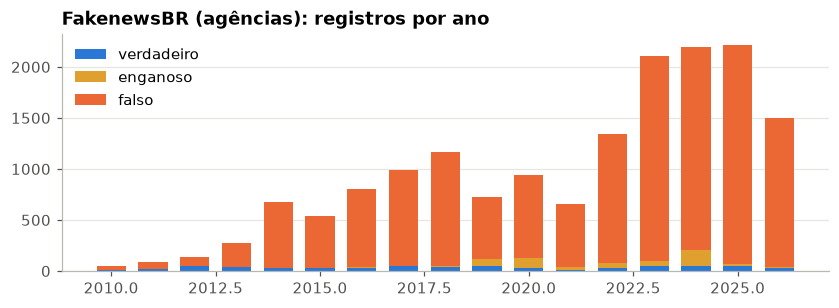

Formato (% dos registros, exceto a 1ª coluna, que é a média de % de palavras em CAIXA ALTA):


,% caixa alta,tem !,curto termina com ponto,curto começa com vídeo/foto,curto em minúsculas
veracidade,,,,,
verdadeiro,1.2,14.1,0.3,13.1,5.0
enganoso,2.1,5.8,4.7,11.9,0.4
falso,3.1,8.0,2.0,12.9,2.6


Fontes mais frequentes por classe:


registros
           fonte                           
verdadeiro e-farsas.com                 431
           g1.globo.com                 112
           coletivobereia.com.br         29
           lupa.uol.com.br               19
enganoso   e-farsas.com                 159
           coletivobereia.com.br        127
           sbtnews.sbt.com.br            87
           noticias.uol.com.br           74
falso      boatos.org                  8313
           e-farsas.com                2618
           g1.globo.com                2450
           lupa.uol.com.br             1343

Uso no modelo do jogo (split_produto):


split_produto,treino,validacao,teste,reserva,fora
veracidade,,,,,
verdadeiro,299,50,81,0,173
enganoso,294,160,23,0,78
falso,363,101,93,13187,1827


Exemplos (texto curto, ou o início do texto):
  [verdadeiro] : vídeo mostra escada 'mortal' durante obra
  [verdadeiro] "O transporte hoje na cidade de São Paulo é bastante subsidiado, acho que mais da metade do valor é pago pelos nossos impostos"
  [enganoso] Vídeo mostra desabafo atual de Ronnie Von contra a violência e autoridades governamentais
  [enganoso] Reportagem desinforma sobre envolvimento de líder da Igreja Presbiteriana do Brasil em inquérito da Polícia Federal
  [falso] Bandidos estão agendando visita técnica da SKY, NET e GVT por carta para poder fazer assalto programado a residências
  [falso] Negociar forex é algo que não apresenta nenhum risco?


In [7]:
perfil("FakenewsBR (agências)")

## 6. FakenewsBR (mensagens)

**O que é.** Mensagens anotadas da FakenewsBR: FakeWhatsApp.BR (grupos de WhatsApp na eleição
de 2018) e COVID19.BR (2020, sem data). Entram as duas classes, só no treino.

**Padrões.**
- **Mesmo formato nas duas classes** (mensagem de rede social), o que ajuda contra o atalho
  "manchete = verdadeiro".
- **Rótulo com ruído**: "verdadeiro" aqui quer dizer "não é desinformação", e inclui
  correntes e comentários. Por isso entram com `origem_rotulo = mensagem` (peso 0,7).
- **Pouco texto curto** (~25%): a maioria é mensagem longa.

,linhas,período,sem data,com texto curto (%),palavras do texto (mediana),palavras do texto curto (mediana)
veracidade,,,,,,
verdadeiro,3928,2018–2018,1087,28.0,27.0,31.0
enganoso,3,2018–2018,1,33.0,13.0,12.0
falso,3151,2018–2018,740,23.0,44.0,48.0
total,7082,2018–2018,1828,26.0,33.0,40.0


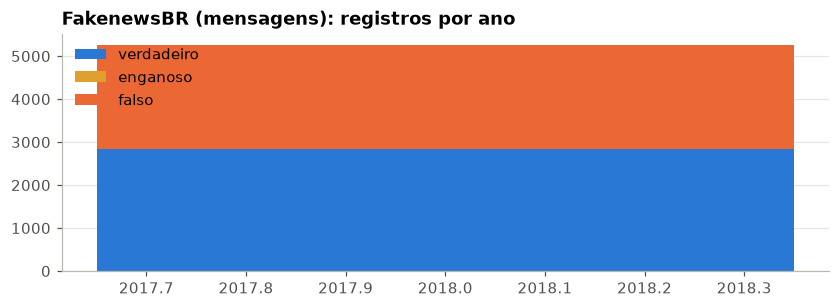

Formato (% dos registros, exceto a 1ª coluna, que é a média de % de palavras em CAIXA ALTA):


,% caixa alta,tem !,curto termina com ponto,curto começa com vídeo/foto,curto em minúsculas
veracidade,,,,,
verdadeiro,8.1,29.1,6.3,0.0,0.2
enganoso,2.8,33.3,0.0,0.0,0.0
falso,10.9,46.2,7.5,0.0,0.0


Fontes mais frequentes por classe:


registros
           fonte                          
verdadeiro FakeWhatsApp.BR_2018       2841
           COVID19.BR                 1087
enganoso   FakeWhatsApp.BR_2018          2
           COVID19.BR                    1
falso      FakeWhatsApp.BR_2018       2411
           COVID19.BR                  740

Uso no modelo do jogo (split_produto):


split_produto,treino
veracidade,
verdadeiro,3928
enganoso,3
falso,3151


Exemplos (texto curto, ou o início do texto):
  [verdadeiro] *_MUITO BOM DIA  AMIGOS_.*
*_QUE DEUS NOS PROTEJA_.*

*_"BRASIL ACIMA DE TUDO DEUS ACIMA DE TODOS""_*
🙏🙏🙏🙌🙌🙌🇧🇷🇧🇷🇧🇷🇧🇷
💦💧💦💧💦💧💦💧💦💧…
  [verdadeiro] O Haddad chegou pra mulher dele e disse: 
- querida segunda-feira depois do segundo turno vc vai dormir com o presidente da republica. Ela respondeu:
- o Bolson…
  [enganoso] Haddad diz que a eleição ja Acabou, agora pede dinheiro para os eleitores.
Vamos Fazer este vídeo rodar o Brasil inteiro de Hoje Para Amanhã!…
  [enganoso] Liberação da Cloroquina pela Anvisa, já com posologia para tratamento do Covid-19:
  [falso] Estão tão desesperados que acabaram de cometer um suicídio, esse vídeo seria a única coisa que eles jamais deveriam ter feito, com certeza o chefe da gangue não…
  [falso] IMPORTANTÍSSIMO!!!! 

Caso o Bolsonaro nao ganhe por causa de fraude.
Pegue seu comprovante de votação, e coloque  o número 17, nele contém seu número de inscri…


In [8]:
perfil("FakenewsBR (mensagens)")

## 7. Portais

**O que é.** Matérias de 9 portais de linhas editoriais variadas, coletadas pela API
WordPress (`coletar_verdadeiras.py`), de 2018 a 2026. Verdadeiras **por suposição** (não
checadas), com `origem_rotulo = portal` (peso 0,7).

**Padrões.**
- **Volume grande e estável** (~2.500 por portal), então servem para completar os
  verdadeiros: no treino, só até igualar os falsos; na validação e no teste, cobrem 2024 em
  diante, que nenhuma outra base cobre. O resto (16.876) fica em `reserva`.
- **Formato de manchete**: texto curto sem ponto final e matéria longa (~360 palavras).

,linhas,período,sem data,com texto curto (%),palavras do texto (mediana),palavras do texto curto (mediana)
veracidade,,,,,,
verdadeiro,21222,2018–2026,0,100.0,364.0,11.0
total,21222,2018–2026,0,100.0,364.0,11.0


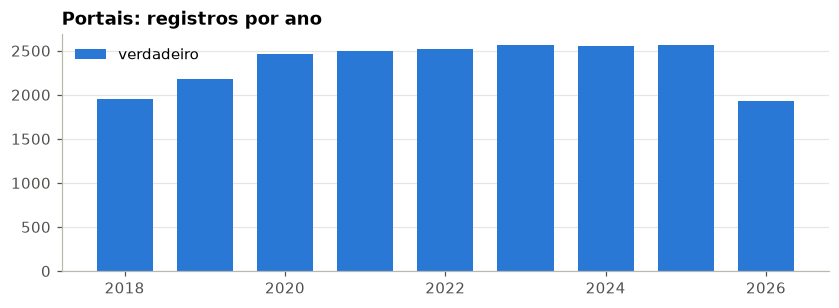

Formato (% dos registros, exceto a 1ª coluna, que é a média de % de palavras em CAIXA ALTA):


,% caixa alta,tem !,curto termina com ponto,curto começa com vídeo/foto,curto em minúsculas
veracidade,,,,,
verdadeiro,1.3,9.4,0.0,0.4,0.2


Fontes mais frequentes por classe:


registros
           fonte                         
verdadeiro poder360.com.br           2518
           infomoney.com.br          2513
           veja.abril.com.br         2500
           brasildefato.com.br       2492

Uso no modelo do jogo (split_produto):


split_produto,treino,validacao,teste,reserva,fora
veracidade,,,,,
verdadeiro,2756,689,872,16876,29


Exemplos (texto curto, ou o início do texto):
  [verdadeiro] Ibovespa fecha em queda pela quarta semana consecutiva, a 96.999 pontos
  [verdadeiro] Stock Pickers que compra commodities: pode isso?


In [9]:
perfil("Portais")

## 8. ClaimPT (fora do dataset)

Notícias da Lusa (português europeu) com afirmações, não-afirmações e quem disse. **Não tem veracidade**, então fica em `claimpt.jsonl`, para avaliar a extração de afirmações pela LLM. O repositório público traz só uma amostra de 20 artigos; o completo exige um Data Use Agreement.

In [10]:
claimpt = pd.read_json(RAIZ / "data" / "processed" / "claimpt.jsonl", lines=True)
afirm = claimpt.explode("afirmacoes").afirmacoes.dropna()
print(f"{len(claimpt)} artigos · {claimpt.afirmacoes.str.len().sum()} afirmações · "
      f"{claimpt.nao_afirmacoes.str.len().sum()} não-afirmações · amostra: {claimpt.amostra.all()}")
pd.DataFrame({"trecho": afirm.str["trecho"].str[:90], "quem disse": afirm.str["quem_disse"].str[0].str["texto"]}).head(8)

20 artigos · 16 afirmações · 68 não-afirmações · amostra: True


,trecho,quem disse
0,"foi convidado para aderir não pelo lado monárquico, no qual, aliás, não insistiam muito, m",Pinto Balsemão
3,"Infelizmente, a rejeição da existência de Israel é um elemento comum entre ambas as fações",o primeiro-ministro israelita
6,"Setenta e cinco anos depois, os judeus ainda são alvo de ataques e ainda sentem a violênci",Yeela Cytrin
6,O Hamas e os seus apoiantes encorajam a erradicação do povo judeu nas redes sociais há ano,Yeela Cytrin
6,"Mesmo antes de os corpos das vítimas de 07 de outubro arrefecerem, o antissemitismo explod",Yeela Cytrin
6,"Nas últimas oito semanas, depois de transmitir publicamente apelos genocidas, Israel começ",A diplomata palestiniana Dima Asfour
7,"A maioria absoluta fechou hospitais e urgências, deixou Portugal numa crise de habitação e",Mariana Mortágua
7,"Estamos na estação da universidade que é o fim de linha do metro sul do Tejo, deixando mil",Mariana Mortágua


## Resumo dos padrões

| Dataset | Formato das classes | Atalho principal | Papel |
|---|---|---|---|
| Fake.br | matéria × matéria | tamanho; um site só nas falsas | verdadeiro e falso pareados |
| FakeRecogna | mensagem × matéria | ponto final, `!`, caixa alta, tamanho | verdadeiro e falso |
| FakeTrue.Br | mensagem × matéria | texto em minúsculas; tamanho | verdadeiro e falso pareados |
| Fact Check API | alegação × alegação | — (formato homogêneo) | enganoso e falso; checagens recentes |
| FakenewsBR (agências) | alegação × alegação | agência sem falsos (corrigido com amostra) | verdadeiros checados e enganosos |
| FakenewsBR (mensagens) | mensagem × mensagem | — (mesmo formato) | verdadeiro e falso no mesmo gênero |
| Portais | manchete/matéria | gênero de texto | verdadeiros recentes |

Os atalhos de formato e tamanho reforçam a decisão de padronizar o texto pela LLM, igual no treino e no uso, e de medir o teste de atalho no conjunto (`eda_2_conjunto.ipynb`).